# Лабораторна робота 6 ІАД


**Завдання:**
1. Здійснити загальні операції з використанням TensorFlow :
    1. Створіть вектор, скаляр, матрицю та тензор зі значеннями на ваш вибір за допомогою `tf.constant()`.
    2. Знайдіть форму, ранг та розмір тензорів, створених у 1.
    3. Створіть два тензори, що містять випадкові значення між 0 та 1, форми `[5, 300]`.
    4. Помножте два тензори, створені в 3, за допомогою множення матриць.
    5. Помножте два тензори, створені в 3, за допомогою скалярного добутку.
    6. Створіть тензор з випадковими значеннями між 0 та 1 форми `[224, 224, 3]`.
    7. Знайдіть мінімальне та максимальне значення тензора, створеного в 6.
    8. Створіть тензор з випадковими значеннями форми `[1, 224, 224, 3]`, а потім стисніть його, щоб змінити форму на `[224, 224, 3]`. 
    9. Створіть тензор форми `[10]`, використовуючи власні значення, а потім знайдіть індекс, який має максимальне значення.
    10. Закодуйте тензор, створений у кроці 9, за допомогою one-hot кодування.
2. Перевірте доступ до графічного процесора
3. Згенерувати набір даних для регресії та класифікації з використанням TensorFlow.
4. Здійснити графічний аналіз наборів даних за допомогою Matplotlib.
5. Відповіді оформити .ipynb документом.
6. Викласти у зазначений репозіторій GitHub в окремій папці з назвою Lab6 де має бути .ipynb файл та необхідні файли з даними


In [13]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


Частина 2: Основні операції з тензорами (Завдання 1-10)
Тут ми створимо різні типи тензорів і виконаємо над ними математичні операції.

In [15]:
scalar = tf.constant(7)
vector = tf.constant([10, 10])
matrix = tf.constant([[1, 2],
                      [3, 4]])
tensor = tf.constant([[[1, 2, 3],
                       [4, 5, 6]],
                      [[7, 8, 9],
                       [10, 11, 12]]])

print("1. Тензори створено.")

def print_tensor_info(name, t):
    print(f"\nInfo for {name}:")
    print(f" Shape (Форма): {t.shape}")
    print(f" Rank (Ранг/ndim): {t.ndim}")
    print(f" Size (Розмір): {tf.size(t).numpy()}")

print_tensor_info("Scalar", scalar)
print_tensor_info("Vector", vector)
print_tensor_info("Matrix", matrix)
print_tensor_info("Tensor", tensor)

tf.random.set_seed(42) 
tensor_A = tf.random.uniform(shape=[5, 300], minval=0, maxval=1)
tensor_B = tf.random.uniform(shape=[5, 300], minval=0, maxval=1)
print(f"\n3. Створено два тензори форми: {tensor_A.shape}")

matrix_mult_result = tf.matmul(tensor_A, tf.transpose(tensor_B))
print(f"\n4. Результат матричного множення (shape): {matrix_mult_result.shape}")

dot_product_result = tf.tensordot(tensor_A, tf.transpose(tensor_B), axes=1)
scalar_result = tf.reduce_sum(tf.multiply(tensor_A, tensor_B))
print(f"\n5. Скалярний добуток (через tensordot shape): {dot_product_result.shape}")
print(f"   Повний скалярний добуток (сума добутків): {scalar_result.numpy()}")

image_tensor = tf.random.uniform(shape=[224, 224, 3], minval=0, maxval=1)
print(f"\n6. Створено 'зображення' з формою: {image_tensor.shape}")

min_val = tf.reduce_min(image_tensor)
max_val = tf.reduce_max(image_tensor)
print(f"\n7. Min: {min_val.numpy()}, Max: {max_val.numpy()}")

tensor_unsqueezed = tf.random.uniform(shape=[1, 224, 224, 3])
print(f"\n8. До squeeze: {tensor_unsqueezed.shape}")
tensor_squeezed = tf.squeeze(tensor_unsqueezed)
print(f"   Після squeeze: {tensor_squeezed.shape}")

my_tensor = tf.constant([0, 5, 20, 3, 8, 1, 99, 4, 2, 7]) 
max_index = tf.argmax(my_tensor)
print(f"\n9. Тензор: {my_tensor.numpy()}")
print(f"   Індекс максимального значення (99): {max_index.numpy()}")

indices_tensor = tf.range(10) # [0, 1, ... 9]
one_hot_tensor = tf.one_hot(indices_tensor, depth=10)
print(f"\n10. One-hot encoding (перші 3 рядки):\n{one_hot_tensor[:3].numpy()}")

1. Тензори створено.

Info for Scalar:
 Shape (Форма): ()
 Rank (Ранг/ndim): 0
 Size (Розмір): 1

Info for Vector:
 Shape (Форма): (2,)
 Rank (Ранг/ndim): 1
 Size (Розмір): 2

Info for Matrix:
 Shape (Форма): (2, 2)
 Rank (Ранг/ndim): 2
 Size (Розмір): 4

Info for Tensor:
 Shape (Форма): (2, 2, 3)
 Rank (Ранг/ndim): 3
 Size (Розмір): 12

3. Створено два тензори форми: (5, 300)

4. Результат матричного множення (shape): (5, 5)

5. Скалярний добуток (через tensordot shape): (5, 5)
   Повний скалярний добуток (сума добутків): 382.345703125

6. Створено 'зображення' з формою: (224, 224, 3)

7. Min: 2.384185791015625e-07, Max: 0.999991774559021

8. До squeeze: (1, 224, 224, 3)
   Після squeeze: (224, 224, 3)

9. Тензор: [ 0  5 20  3  8  1 99  4  2  7]
   Індекс максимального значення (99): 6

10. One-hot encoding (перші 3 рядки):
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


Частина 3: Перевірка GPU

In [16]:
print("Перевірка GPU:")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU знайдено: {gpu_devices}")
    print(f"Деталі: {tf.sysconfig.get_build_info()['cuda_version'] if 'cuda_version' in tf.sysconfig.get_build_info() else 'N/A'}")
else:
    print("GPU не знайдено. Використовується CPU.")

Перевірка GPU:
GPU не знайдено. Використовується CPU.


Частина 4: Генерація даних та Графічний аналіз (Regression & Classification)
Ми згенеруємо синтетичні дані безпосередньо за допомогою TensorFlow та візуалізуємо їх через Matplotlib.

А. Регресія (Лінійна залежність з шумом)

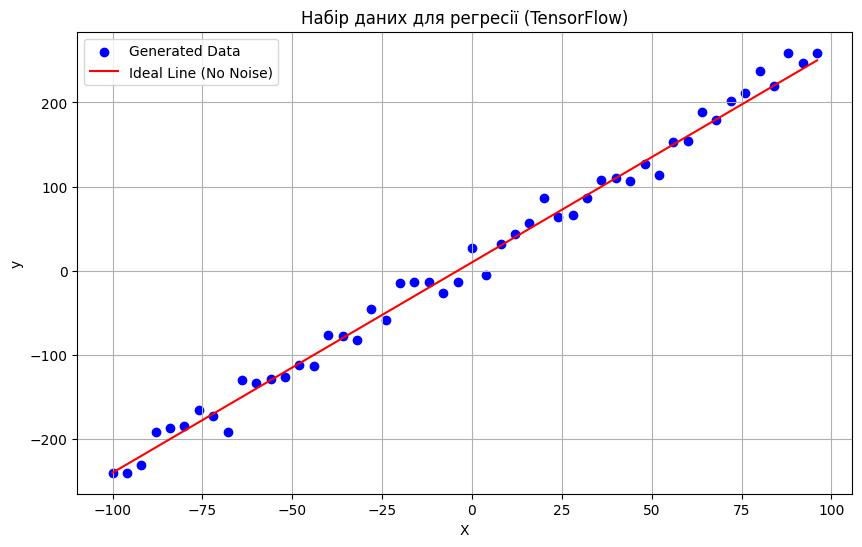

In [17]:
X_reg = tf.range(-100, 100, 4) 
X_reg = tf.cast(X_reg, dtype=tf.float32) 

w_true = 2.5
b_true = 10.0
noise = tf.random.normal(shape=X_reg.shape, mean=0.0, stddev=15.0) 

y_reg = X_reg * w_true + b_true + noise


plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, c='b', label='Generated Data')
plt.plot(X_reg, X_reg * w_true + b_true, c='r', label='Ideal Line (No Noise)')
plt.title("Набір даних для регресії (TensorFlow)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Б. Класифікація (Два класи точок)

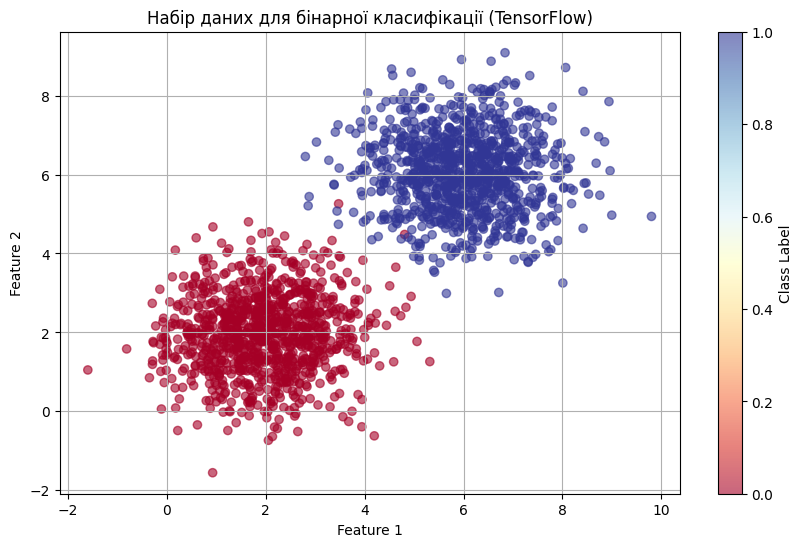

In [18]:
n_samples = 1000

class_0_x = tf.random.normal(shape=[n_samples], mean=2.0, stddev=1.0)
class_0_y = tf.random.normal(shape=[n_samples], mean=2.0, stddev=1.0)
class_0 = tf.stack([class_0_x, class_0_y], axis=1)

class_1_x = tf.random.normal(shape=[n_samples], mean=6.0, stddev=1.0)
class_1_y = tf.random.normal(shape=[n_samples], mean=6.0, stddev=1.0)
class_1 = tf.stack([class_1_x, class_1_y], axis=1)

X_class = tf.concat([class_0, class_1], axis=0)
y_class = tf.concat([tf.zeros(n_samples), tf.ones(n_samples)], axis=0)

plt.figure(figsize=(10, 6))
plt.scatter(X_class[:, 0], X_class[:, 1], c=y_class, cmap=plt.cm.RdYlBu, alpha=0.6)
plt.title("Набір даних для бінарної класифікації (TensorFlow)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class Label")
plt.grid(True)
plt.show()